In [3]:
from google.colab import files

uploaded = files.upload()

Saving Twitter_Data.csv to Twitter_Data.csv


In [4]:
import pandas as pd

df = pd.read_csv('Twitter_Data.csv')

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [5]:
print(df.columns)

Index(['clean_text', 'category'], dtype='object')


In [6]:
print(df.shape)

(162980, 2)


In [7]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [8]:
df.isnull().sum()

,0
clean_text,4
category,7


In [9]:
df = df.dropna()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['category']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(130375, 5000)
(32594, 5000)


In [12]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1. 1. 1. 0. 0. 1. 0. 1. 1. 1.]


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.7374363379763147


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.91      0.42      0.57      7152
         0.0       0.88      0.67      0.76     11067
         1.0       0.65      0.95      0.78     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 2983   538  3631]
 [   94  7367  3606]
 [  207   482 13686]]


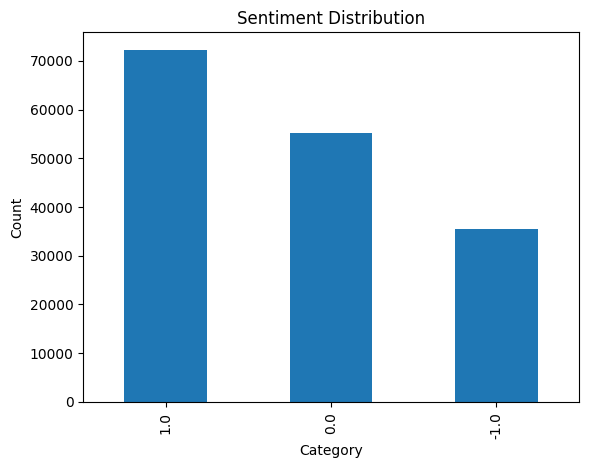

In [17]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [18]:
sample = ["India is developing very fast"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print(prediction)

[1.]


In [19]:
sample = ["India is developing very fast"]

sample_vector = vectorizer.transform(sample)

pred = model.predict(sample_vector)[0]

if pred == 1:
    print("Positive 😊")
elif pred == 0:
    print("Neutral 😐")
else:
    print("Negative 😞")

Positive 😊
